Tweet Generation Iterative Workflow:

<pre>
               Input (Tweet topic)
                         |
               Generate tweet on topic
                         |                  (Iterate until we get the best tweet)
                Evaluate Tweet <-----------------------------------
                         |                                        |
    +--------------------+---------------------+                  |
    |                                          |                  |
  Approved                                 Needs_improvement      |
    |                                          |                  |
   END                                     Optimize the Tweet -----
</pre>


In [112]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage
import operator
load_dotenv()

True

In [113]:
generate_tweet_llm = ChatOpenAI(model = "gpt-4o-mini")
evaluate_tweet_llm = ChatOpenAI(model = "gpt-4o-mini")
optimize_tweet_llm = ChatOpenAI(model = "gpt-4o")

In [114]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved","needs_improvement"] = Field(description="Field evaluation categories")
    feedback:str = Field(description="Feedback of the filed")

evaluate_tweet_llm = evaluate_tweet_llm.with_structured_output(TweetEvaluation)

In [115]:
class TweetGenerator(TypedDict):
    topic:str
    tweet:str
    evaluation: Literal["approved","needs_improvement"]
    feedback:str
    iteration:int
    max_iteration:int

In [116]:
graph = StateGraph(TweetGenerator)

In [117]:
def tweet_generate(state:TweetGenerator):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]

    # send generator_llm
    tweet = generate_tweet_llm.invoke(messages).content

    return {'tweet':tweet}

In [118]:
def tweet_evaluate(state:TweetGenerator):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
            Evaluate the following tweet:

            Tweet: "{state['tweet']}"

            Use the criteria below to evaluate the tweet:

            1. Originality – Is this fresh, or have you seen it a hundred times before?
            2. Humor – Did it genuinely make you smile, laugh, or chuckle?
            3. Punchiness – Is it short, sharp, and scroll-stopping?
            4. Virality Potential – Would people retweet or share it?
            5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Don't end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"
        - feedback: One paragraph explaining the strengths and weaknesses
        """)
    ]

    response = evaluate_tweet_llm.invoke(messages)

    return {'evaluation':response.evaluation,'feedback':response.feedback}


In [119]:
def route(state:TweetGenerator):
    if state['evaluation'] == 'approved' or state['iteration']>=state['max_iteration']:
        return "approved"
    else:
        return "needs_improvement"

In [120]:
def tweet_optimize(state:TweetGenerator):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]

    response = optimize_tweet_llm.invoke(messages).content

    iteration = state['iteration']+1

    return {'tweet':response,'iteration':iteration}


In [121]:
graph.add_node("tweet_generate",tweet_generate)
graph.add_node("tweet_evaluate",tweet_evaluate)
graph.add_node("tweet_optimize",tweet_optimize)

In [122]:
graph.add_edge(START,"tweet_generate")
graph.add_edge("tweet_generate","tweet_evaluate")
graph.add_conditional_edges("tweet_evaluate",route,{'approved':END,'needs_improvemnt':"tweet_optimize"})
graph.add_edge("tweet_optimize","tweet_evaluate")


In [123]:
workflow = graph.compile()

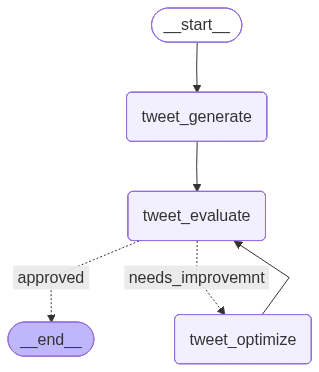

In [124]:
workflow

In [125]:
input ={
    'topic':'Pollution in Delhi',
    'iteration':1,
    'max_iteration':5
}

workflow.invoke(input)

{'topic': 'Pollution in Delhi',
 'tweet': 'Breathing in Delhi’s air is like ordering a mystery box from the universe—will it be smog, dust, or a surprise UFO sighting? My lungs just filed a complaint for harassment and asked for a vacation in the Himalayas! ✈️😷 #DelhiPollution #AirQualityQuirks',
 'evaluation': 'approved',
 'feedback': "This tweet scores high on originality, as comparing Delhi's air quality to a 'mystery box from the universe' is a fresh and creative analogy not commonly seen. The humor is evident, especially with the clever complaint from the lungs, delivering a chuckle. It maintains a punchy format, keeping readers engaged without lengthy explanations. With current environmental concerns, the tweet has strong virality potential, likely prompting shares and retweets. It’s well-structured, under the character limit, and avoids traditional joke formats, making it an effective and entertaining tweet.",
 'iteration': 1,
 'max_iteration': 5}

In [126]:
input ={
    'topic':'Tissue Paperaskddsajdfjfdi',
    'iteration':1,
    'max_iteration':5
}

workflow.invoke(input)

{'topic': 'Tissue Paperaskddsajdfjfdi',
 'tweet': "Tissue paper is the glamorous teen of the household—soft, delicate, and somehow always showing up in awkward moments. One moment you're blowing your nose, the next, it's starring in a dramatic breakup scene because you need it to wipe away your tears. 🥲💔 #TissueDrama",
 'evaluation': 'approved',
 'feedback': "This tweet is original, presenting a fresh and relatable perspective on tissue paper that we don't often see. The humor is subtle yet effective, as it captures the often overlooked role of tissue paper in emotional moments, making it likely to elicit a smile. The phrasing is punchy enough to be scroll-stopping, and the use of emojis enhances the emotional connection without overdoing it. Its relatable content could easily encourage retweets and shares, tapping into common experiences. Overall, it fits well within the tweet format guidelines.",
 'iteration': 1,
 'max_iteration': 5}